In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ielādējam datus no 2. nedēļas mapes
df = pd.read_csv('../week2/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
df.head()

Datu kopa: 12330 rindas, 28 kolonnas


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,TotalDuration
0,0,-0.457191,0,-0.244931,1,-0.624348,3.667189,3.229316,-0.317178,0.0,...,0,0,0,0,0,0,0,0,1,-1.326469
1,0,-0.457191,0,-0.244931,2,-0.590903,-0.457683,1.171473,-0.317178,0.0,...,0,0,0,0,0,0,0,0,1,-1.293024
2,0,-0.457191,0,-0.244931,1,-0.624348,3.667189,3.229316,-0.317178,0.0,...,0,0,0,0,0,0,0,0,1,-1.326469
3,0,-0.457191,0,-0.244931,2,-0.622954,0.573535,1.994610,-0.317178,0.0,...,0,0,0,0,0,0,0,0,1,-1.325076
4,0,-0.457191,0,-0.244931,10,-0.296430,-0.045196,0.142551,-0.317178,0.0,...,0,0,0,0,0,0,0,0,1,-0.998552


In [2]:
# Target mainīgais - vai klients veica pirkumu
y = df['Revenue']

# Features - visas pārējās kolonnas
X = df.drop('Revenue', axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target sadalījums:\n{y.value_counts()}")
print(f"\nPirkumu īpatsvars: {y.mean():.1%}")

Features skaits: 27
Target sadalījums:
Revenue
0    10422
1     1908
Name: count, dtype: int64

Pirkumu īpatsvars: 15.5%


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")
print(f"\nTarget sadalījums treniņa kopā: \n{y_train.value_counts(normalize=True).round(3)}")

Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas

Target sadalījums treniņa kopā: 
Revenue
0    0.845
1    0.155
Name: proportion, dtype: float64


Šajā solī mēs izmantojām stratify=y, lai nodrošinātu, ka pirkumu proporcija (~15%) ir vienāda gan treniņa, gan testa kopā. Sadalījums $80/20$ ir piemērots, jo tas sniedz pietiekami daudz datu modeļa apmācībai, vienlaikus atstājot pietiekamu apjomu objektīvai pārbaudei.

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Izveido un uztrenē modeli
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Prognozes uz testa kopas
dt_pred = dt_model.predict(X_test)

print("=== Decision Tree rezultāti ===")
print(classification_report(y_test, dt_pred))

=== Decision Tree rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.73      0.56      0.63       382

    accuracy                           0.90      2466
   macro avg       0.82      0.76      0.79      2466
weighted avg       0.89      0.90      0.89      2466



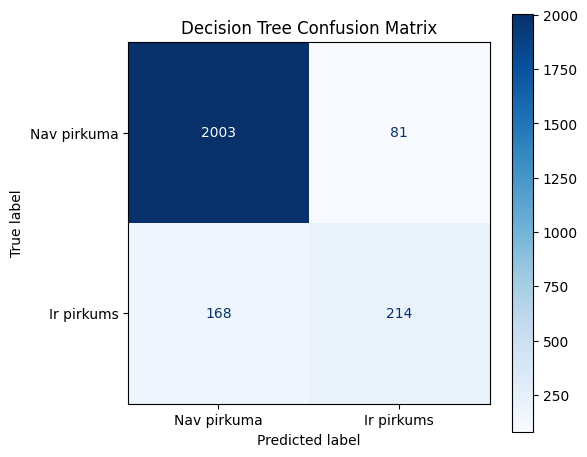

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Blues', ax=ax
)
ax.set_title('Decision Tree Confusion Matrix')
plt.tight_layout()
plt.show()

Modelis prognozē pirkumus ar 73% precizitāti (precision), kas nozīmē, ka lielākā daļa prognozēto pircēju tiešām veic pirkumu, taču tas spēja atpazīt tikai 56% no visiem reālajiem pircējiem (recall), tādējādi gandrīz pusi pirkumu palaižot garām. Kontekstā ar confusion matrix skaitļiem, mēs redzam 81 False Positive (FP) gadījumu, kas biznesam nozīmē velti iztērētu mārketinga budžetu (piemēram, nosūtītu atlaidi klientam, kurš neiepērkas), un 168 False Negative (FN) gadījumus, kas nozīmē nesaņemtu peļņu no klienta, kurš bija gatavs pirkt. DataShop gadījumā sāpīgāks ir FN scenārijs, jo zaudēta pārdošanas iespēja parasti izmaksā dārgāk nekā neliela atlaide. Salīdzinot modeļa veiktspēju, pazīmju par overfitting nav, jo testa precizitāte (0.899) ir ļoti tuva treniņa datiem (0.912), kas norāda, ka modelis ir iemācījies vispārīgas likumsakarības, nevis vienkārši iegaumējis treniņa kopu.

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Izveido un uztrenē modeli (max_depth=10, lai modelis būtu jaudīgāks)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Prognozes uz testa kopas
rf_pred = rf_model.predict(X_test)

print("=== Random Forest rezultāti ===")
print(classification_report(y_test, rf_pred))

=== Random Forest rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2084
           1       0.76      0.55      0.64       382

    accuracy                           0.90      2466
   macro avg       0.84      0.76      0.79      2466
weighted avg       0.90      0.90      0.90      2466



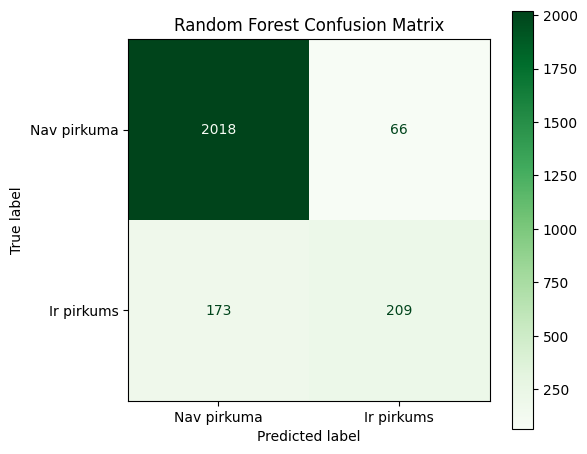

In [7]:
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Greens', # Random Forest tradicionāli vizualizējam zaļā krāsā
    ax=ax
)
ax.set_title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

Random Forest modelis uzrāda 76% precizitāti (precision) un 55% atpazīstamību (recall) pirkumu klasei, rezultātā sasniedzot 0.64 F1 score. Salīdzinot ar Decision Tree, šeit ir mazāks kļūdaini pozitīvo gadījumu skaits (66 FP), kas biznesam nozīmē retāku mārketinga budžeta tērēšanu veltīgi. Tomēr modelis joprojām palaiž garām ievērojamu daļu pircēju (173 FN), kas ir nedaudz vairāk nekā iepriekšējam modelim. Random Forest parasti mazāk pārmācās nekā viens lēmumu koks, jo tas izmanto "pūļa gudrības" principu, apvienojot daudzu koku prognozes un tādējādi samazinot kļūdu risku, ko varētu radīt viena atsevišķa koka specifiskas novirzes.

In [8]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("=== Logistic Regression rezultāti ===")
print(classification_report(y_test, lr_pred))

=== Logistic Regression rezultāti ===
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.75      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



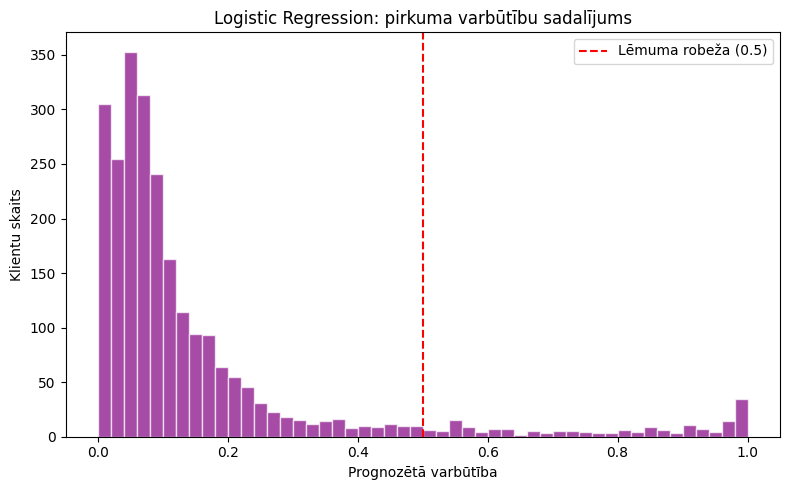

In [9]:
lr_proba = lr_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 5))
plt.hist(lr_proba, bins=50, color='purple', edgecolor='white', alpha=0.7)
plt.axvline(x=0.5, color='red', linestyle='--', label='Lēmuma robeža (0.5)')
plt.title('Logistic Regression: pirkuma varbūtību sadalījums')
plt.xlabel('Prognozētā varbūtība')
plt.ylabel('Klientu skaits')
plt.legend()
plt.tight_layout()
plt.show()

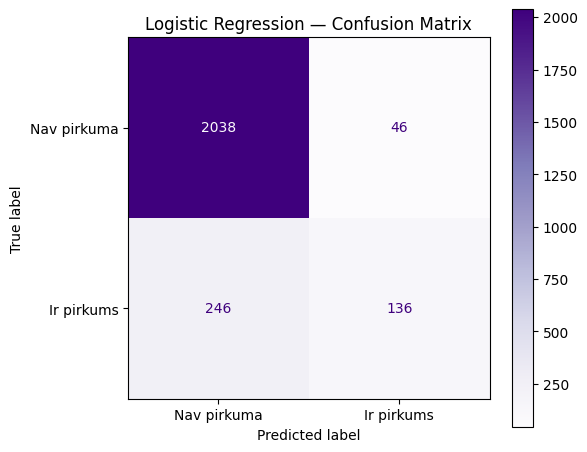

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Purples', ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

### Logistic Regression interpretācija

Logistic Regression uzrāda F1 score 0.48 pirkumu klasei — tas ir zemāks nekā Random Forest (0.55) un Decision Tree.

**Varbūtību histogramma** parāda, ka lielākā daļa klientu saņem zemu pirkuma varbūtību (tuvu 0), un tikai neliela grupa — augstu (tuvu 1). Modelis samērā labi atdala abas grupas, bet daudzi potenciālie pircēji paliek "pelēkajā zonā" zem 0.5 robežas.

**Biznesa priekšrocība:** Logistic Regression dod varbūtības katram klientam, nevis tikai "jā/nē". Tas ļauj sakārtot klientus pēc prioritātes — piemēram, sūtīt atlaides vispirms tiem, kam pirkuma varbūtība ir augstākā.

**FP/FN salīdzinājums:** Logistic Regression ir ļoti piesardzīgs — tikai 46 FP (mazāk velti tērēta nauda), bet 246 FN (daudz zaudētu pircēju). Random Forest labāk atrod pircējus (FN=173), bet nedaudz vairāk kļūdās ar viltus prognozēm (FP=66).

In [11]:
from sklearn.metrics import f1_score

dt_f1 = f1_score(y_test, dt_pred)
rf_f1 = f1_score(y_test, rf_pred)
lr_f1 = f1_score(y_test, lr_pred)

results = pd.DataFrame({
    'Modelis': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'F1 Score': [dt_f1, rf_f1, lr_f1]
})

print(results.to_string(index=False))

            Modelis  F1 Score
      Decision Tree  0.632201
      Random Forest  0.636225
Logistic Regression  0.482270


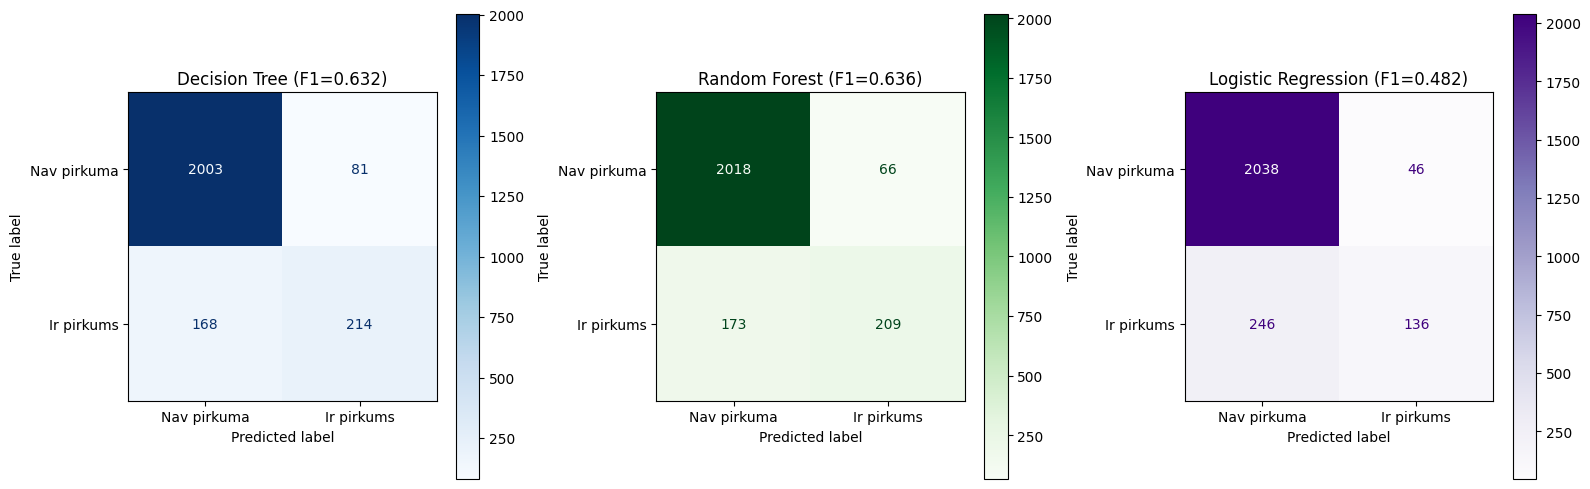

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Decision Tree (F1={dt_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title(f'Random Forest (F1={rf_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Purples', ax=axes[2]
)
axes[2].set_title(f'Logistic Regression (F1={lr_f1:.3f})')

plt.tight_layout()
plt.show()

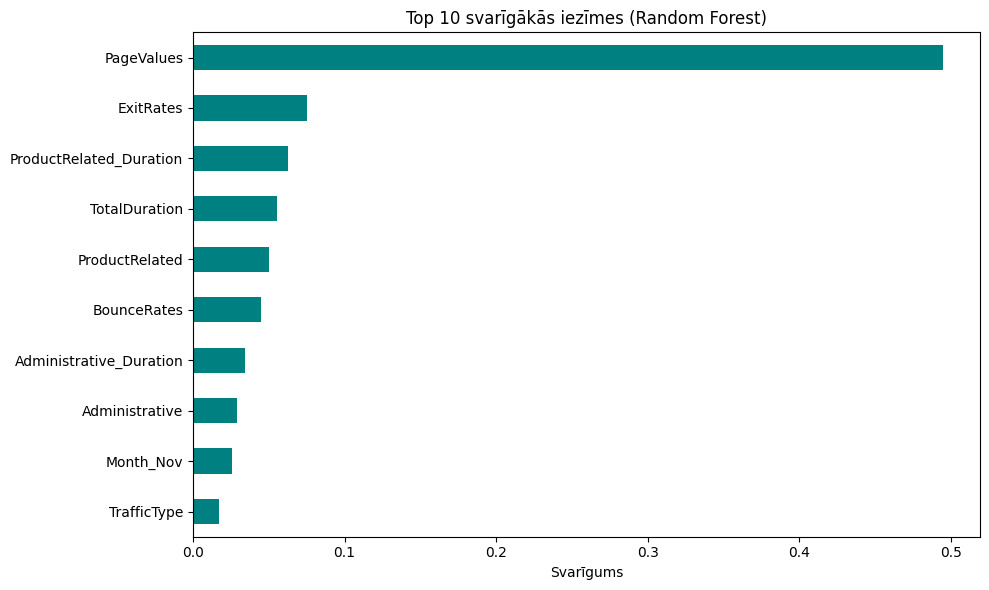

In [13]:
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 svarīgākās iezīmes (Random Forest)')
plt.xlabel('Svarīgums')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Modeļu salīdzinājums un secinājumi

**Labākais modelis ir Random Forest (F1=0.636)**, bet Decision Tree ir ļoti tuvu (F1=0.632). Logistic Regression atpaliek (F1=0.482), jo tas ir piesardzīgāks un daudz pircēju palaiž garām.

**Kāpēc F1, nevis accuracy?** Ja modelis vienmēr teiktu "nepirks", tā accuracy būtu ~85% (jo tikai 15% klientu pērk). Bet F1 pirkumu klasei būtu 0 — modelis neko neatrod. Tāpēc F1 ir godīgāks rādītājs nesabalansētiem datiem.

**Feature importance:** PageValues dominē ar ~50% svarīgumu — cik vērtīgas lapas klients apskatīja, visvairāk ietekmē pirkuma prognozi. Tas ir loģiski — ja klients skatās produktu lapas un liek preces grozā, viņš ir tuvāk pirkumam. Nākamās svarīgākās ir ExitRates un ProductRelated_Duration.

**Logistic Regression priekšrocība:** lai gan F1 ir zemāks, šis modelis dod varbūtības katram klientam. E-komercijas vadītājs var sakārtot klientus pēc pirkuma varbūtības un piešķirt mārketinga budžetu prioritāri — piemēram, sūtīt atlaides tiem 500 klientiem ar augstāko varbūtību.

**Ja es būtu e-komercijas vadītājs**, es izmantotu Random Forest kā galveno modeli (labākais F1), bet papildus lietotu Logistic Regression varbūtības klientu prioritizēšanai mārketinga kampaņās.

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

print("=== KNN rezultāti ===")
print(classification_report(y_test, knn_pred))

=== KNN rezultāti ===
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      2084
           1       0.56      0.22      0.31       382

    accuracy                           0.85      2466
   macro avg       0.72      0.59      0.62      2466
weighted avg       0.82      0.85      0.82      2466



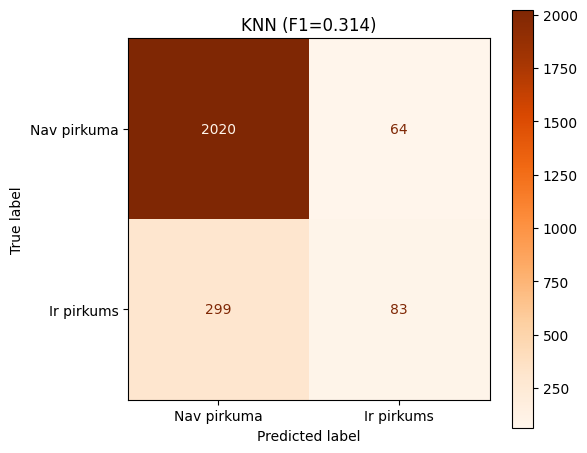

In [15]:
knn_f1 = f1_score(y_test, knn_pred)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, knn_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Oranges', ax=ax
)
ax.set_title(f'KNN (F1={knn_f1:.3f})')
plt.tight_layout()
plt.show()

### KNN interpretācija

KNN uzrāda viszemāko F1 score (0.314) no visiem četriem modeļiem. Modelis atrod tikai 22% pircēju (recall), kas nozīmē, ka 299 potenciālie pircēji tika palaisti garām (FN).

Galvenais iemesls, kāpēc KNN strādā vājāk, visticamāk ir datu mērogošana — KNN rēķina attālumu starp punktiem, tāpēc iezīmes ar lielāku skalu (piemēram, PageValues ar vērtībām līdz simtiem) dominē pār mazākām iezīmēm. Ja dati tiktu standartizēti (StandardScaler), rezultāti varētu uzlaboties.

KNN priekšrocība ir vienkāršība — nav trenēšanas posma, tas vienkārši "atceras" visus datus. Bet trūkums ir lēnums uz lielām datu kopām un jutīgums pret mērogošanu.

K=1 būtu riskanti, jo modelis skatītos tikai uz vienu tuvāko kaimiņu — tas nozīmē augstu jutīgumu pret troksni datos. Lielākas K vērtības (piemēram, 7 vai 11) padarītu modeli stabilāku.